In [1]:
# Import libraries
from pathlib import Path

import geopandas as gpd 

import pandas as pd
import numpy as np 
import xarray as xr 
import matplotlib.pyplot as plt 
from pygridsio import plot_grid, read_grid, resample_grid
from shapely.geometry import box

from pythermogis.aquifer import Aquifer 
from pythermogis.doublet import ThermoGISDoublet
from pythermogis.settings import UTCSettings

In [2]:
# Input and output paths
ROOT      = Path().resolve().parent
RAW       = ROOT / 'data' / 'raw'
PROCESSED = ROOT / 'data' / 'processed'
OUTPUT    = ROOT / 'output'
OUTPUT.mkdir(parents=True, exist_ok=True)

### ROSL_ROSLU Grid

In [3]:
# Utrecht Boundaries
# Utrecht province boundary
utrecht_province = gpd.read_file(PROCESSED /"utrecht_province.shp") 
utrecht_province = utrecht_province.to_crs(epsg=28992) 

# Utrecht city boundary 
utrecht_city = gpd.read_file(PROCESSED / "utrecht_city.shp") 
utrecht_city = utrecht_city.to_crs(epsg=28992)

In [4]:
# Known well coordinates
wells = {
    "BLT-01": (141577.55, 456881.76),
    "EVD-01": (136997, 441189),
    "JUT-01": (134098, 451726),
    "PKP-01": (118503.09, 453402.51)
}

### Aquifer Definition

In [5]:
new_cellsize = 1000

thickness = resample_grid(
    read_grid(RAW / "ROSL_ROSLU_thickness_p50.nc"), new_cellsize=new_cellsize
)
ntg = resample_grid(
    read_grid(RAW / "ROSL_ROSLU_net_to_gross.nc"), new_cellsize=new_cellsize
)
porosity = (
    resample_grid(
        read_grid(RAW / "ROSL_ROSLU_porosity.nc"), new_cellsize=new_cellsize
    )
    / 100
)
depth = resample_grid(
    read_grid(RAW / "ROSL_ROSLU_depth.nc"), new_cellsize=new_cellsize
)
permeability = resample_grid(
    read_grid(RAW / "ROSL_ROSLU_permeability_p50.nc"), new_cellsize=new_cellsize
)
temperature = resample_grid(
    read_grid(RAW / "ROSL_ROSLU_temperature.nc"), new_cellsize=new_cellsize
)

# Clipping grid
crs = "EPSG:28992"
minx_clip, maxx_clip = 100_000, 180_000
miny_clip, maxy_clip = 420_000, 490_000
geometry = gpd.GeoSeries(
    [box(minx_clip, miny_clip, maxx_clip, maxy_clip)], crs=crs
)

def clip(grid):
    return grid.rio.write_crs(crs).rio.clip(geometry, all_touched=True, drop=True)

thickness    = clip(thickness)
ntg          = clip(ntg) 
porosity     = clip(porosity) 
depth        = clip(depth)
permeability = clip(permeability)
temperature  = clip(temperature)

utrecht_mask = xr.where(thickness.isnull(), 1, float('nan'))

baseline_aquifer = Aquifer(
    thickness=thickness,
    ntg=ntg,
    porosity=porosity,
    depth=depth,
    permeability=permeability,
    temperature=temperature,
    mask=utrecht_mask,
)

### Baseline Simulation

In [6]:
run_simulation = True
if (OUTPUT / "baseline_results.nc").exists and not run_simulation:
    results = xr.load_dataset(OUTPUT / "baseline_results.nc")
else:
    doublet_normal = ThermoGISDoublet(aquifer=baseline_aquifer)
    baseline_results = doublet_normal.simulate(
        p_values=None,
        chunk_size=100_000
    ).to_dataset()
    baseline_results.to_netcdf(
        OUTPUT / "baseline_results.nc"
    )  # write doublet simulation results to file
print("ready with simulation")

ready with simulation


In [8]:
baseline_viable_df = baseline_results.to_dataframe().dropna().reset_index()

baseline_viable_gdf = gpd.GeoDataFrame(
    baseline_viable_df,
    geometry=gpd.points_from_xy(baseline_viable_df.x, baseline_viable_df.y),
    crs="EPSG:28992"  # RD New (Dutch coordinate system) — change if your coords are in WGS84 (4326)
) 

                        
baseline_viable_gdf.drop(columns="geometry").to_csv(OUTPUT / "baseline_viable.csv", index=False)

print(f"Viable points in Utrecht: {len(baseline_viable_gdf)}")
print(baseline_viable_gdf[['x', 'y', 'npv', 'temperature', 'power']].sort_values('power', ascending=False).head(20))

Viable points in Utrecht: 4971
             x         y       npv  temperature     power
2927  143000.0  472000.0 -3.512282    70.182755  6.823136
2856  142000.0  472000.0 -3.284163    67.215759  6.772892
2930  143000.0  475000.0 -4.565960    79.945259  6.725198
3000  144000.0  474000.0 -4.771787    82.187698  6.696338
2426  136000.0  468000.0 -3.131222    64.006599  6.667943
2929  143000.0  474000.0 -4.486869    78.956474  6.614851
2859  142000.0  475000.0 -4.243281    76.470955  6.612739
2998  144000.0  472000.0 -4.197007    76.489937  6.588179
2786  141000.0  473000.0 -3.591482    69.462921  6.554338
2425  136000.0  467000.0 -3.439682    66.602409  6.515388
2495  137000.0  466000.0 -3.430171    66.252480  6.508656
2843  142000.0  459000.0 -3.413288    67.314423  6.504634
2773  141000.0  460000.0 -3.486663    67.521576  6.481684
2565  138000.0  465000.0 -3.490025    66.622040  6.468997
2005  130000.0  473000.0 -3.571011    68.691078  6.449952
2914  143000.0  459000.0 -3.463837    67.

### Baseline Simulation — Key Observations

| | Finding |
|---|---|
| **Spatial Coverage** | 4,971 viable points — strong coverage across Utrecht |
| **Max Power** | ~6.8 MWth — below 15MWth & 10 MWth targets, just above 5 MWth |
| **Economics** | All NPVs negative — BaseCase not viable without intervention |
| **Temperature** | 64–82°C — suitable for direct heat & heat pump, borderline for ORC |

> BaseCase direct heat alone cannot meet Utrecht's thermal targets or
> break even economically — this motivates our enhanced scenarios: **STIM**, **HP**,
> **STIM+HP**, and **ORC**.

### Heat Pump

In [9]:
settings_heatpump = UTCSettings(
    use_heatpump=True,
    goal_temperature=70,
    dh_return_temp=40,
    use_kestin_viscosity=True,
    heat_pump_capex=600,
    heat_pump_opex=60,
    heat_pump_alternative_heating_price=2.8,
    capex_constant=0.5,
    capex_variable=600,
    heat_exchanger_efficiency=0.95,
    heat_exchanger_parasitic=0.05,
    min_production_temp=40,
    max_cooling_temperature_range=55,
    load_hours=6000,
    utc_cutoff=10,
)

In [10]:
doublet_hp = ThermoGISDoublet(aquifer=baseline_aquifer, settings=settings_heatpump)
hp_results = doublet_hp.simulate().to_dataset() 
hp_viable_df = hp_results.to_dataframe().dropna().reset_index()

hp_viable_gdf = gpd.GeoDataFrame(
    hp_viable_df,
    geometry=gpd.points_from_xy(hp_viable_df.x, hp_viable_df.y),
    crs="EPSG:28992",
)

hp_results.to_netcdf(OUTPUT / "hp_results.nc")
hp_viable_gdf.drop(columns="geometry").to_csv(OUTPUT / "hp_viable.csv", index=False)

print(f"Viable points in Utrecht: {len(hp_viable_gdf)}")
print(hp_viable_gdf[['x', 'y', 'npv', 'temperature', 'power', 'heat_pump_power', 'cophp']].sort_values('power', ascending=False).head(20))

c:\Users\sadar\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in ? (vectorized)
  outputs = ufunc(*args, out=...)


Viable points in Utrecht: 4971
             x         y       npv  temperature     power  heat_pump_power  \
3558  152000.0  464000.0  4.108828    51.352375  7.345870         4.898457   
3488  151000.0  465000.0  4.953735    54.603619  7.127228         3.935891   
3557  152000.0  463000.0  4.545122    53.628719  7.056137         4.140793   
3487  151000.0  464000.0  4.890056    54.939381  7.020142         3.794453   
3553  152000.0  459000.0  4.651229    54.898773  6.812389         3.693847   
3417  150000.0  465000.0  5.473645    58.455997  6.780900         2.820263   
3481  151000.0  458000.0  4.696813    55.397968  6.749525         3.540903   
3556  152000.0  462000.0  4.876891    56.418720  6.712311         3.278800   
3552  152000.0  458000.0  4.535247    55.264648  6.655604         3.524077   
3482  151000.0  459000.0  4.965368    57.179287  6.623988         3.057237   
3625  153000.0  460000.0  4.741468    56.809189  6.527898         3.099781   
3554  152000.0  460000.0  4.94001

### Heat Pump Scenario — Key Observations

| | Finding |
|---|---|
| **Spatial Coverage** | 4,971 viable points — strong coverage across Utrecht |
| **Max Power** | ~7.3 MWth — below 15MWth & 10 MWth targets, just above 5 MWth |
| **Economics** | Positive NPVs |
| **Temperature** | 51-64°C Lower temperatures now viable|

> Adding a heat pump is the minimum intervention needed for economic
> viability in Utrecht

### Stimulation

In [11]:
settings_stimulation = UTCSettings(
    # Enable stimulation
    use_well_stimulation=True,
    added_skin_injector=-3.5,
    added_skin_producer=-3.5,
    max_kh_stimulation=20.0,     
)

In [12]:
doublet_stim = ThermoGISDoublet(aquifer=baseline_aquifer, settings=settings_stimulation)
stim_results = doublet_stim.simulate().to_dataset() 
stim_viable_df = stim_results.to_dataframe().dropna().reset_index()
stim_viable_gdf = gpd.GeoDataFrame(
    stim_viable_df,
    geometry=gpd.points_from_xy(stim_viable_df.x, stim_viable_df.y),
    crs="EPSG:28992",
)

stim_results.to_netcdf(OUTPUT / "stim_results.nc")                         
stim_viable_gdf.drop(columns="geometry").to_csv(OUTPUT / "stim_viable.csv", index=False)

print(f"Viable points in Utrecht: {len(stim_viable_gdf)}")
print(stim_viable_gdf[['x', 'y', 'npv', 'temperature', 'power', 'heat_pump_power']].sort_values('power', ascending=False).head(20))

c:\Users\sadar\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in ? (vectorized)
  outputs = ufunc(*args, out=...)


Viable points in Utrecht: 4971
             x         y       npv  temperature      power  heat_pump_power
2930  143000.0  475000.0 -2.855551    79.945259  11.203570              0.0
3000  144000.0  474000.0 -3.047459    82.187698  11.188346              0.0
2927  143000.0  472000.0 -1.987149    70.182755  11.025143              0.0
2929  143000.0  474000.0 -2.816626    78.956474  11.016004              0.0
2859  142000.0  475000.0 -2.632491    76.470955  10.927110              0.0
2998  144000.0  472000.0 -2.587176    76.489937  10.890273              0.0
2856  142000.0  472000.0 -1.847312    67.215759  10.835706              0.0
2858  142000.0  474000.0 -2.764282    76.624001  10.660308              0.0
2999  144000.0  473000.0 -3.355318    82.692703  10.638774              0.0
2786  141000.0  473000.0 -2.151197    69.462921  10.606763              0.0
2005  130000.0  473000.0 -2.135298    68.691078  10.477469              0.0
2843  142000.0  459000.0 -2.020359    67.314423  10.47412

### Stimulation Scenario — Key Observations

| | Finding |
|---|---|
| **Spatial Coverage** | 4,971 viable points — strong coverage across Utrecht |
| **Max Power** | ~11.2 MWth — 10 MWth target met, 15 MWth not yet|
| **Economics** | Negative NPVs |
| **Temperature** | 66-83°C |

> Stimulation nearly doubles thermal output and unlocks the 10 MWth
> target  but economics remain negative

### Stimulation + Heat Pump

In [13]:
settings_stimulation_heatpump = UTCSettings(
    # Stimulation
    use_well_stimulation=True,
    added_skin_injector=-3.5,
    added_skin_producer=-3.5,
    max_kh_stimulation=20.0,

    # Heat pump — identical to settings_heatpump
    use_heatpump=True,
    goal_temperature=70,
    dh_return_temp=40,
    use_kestin_viscosity=True,
    heat_pump_capex=600,
    heat_pump_opex=60,
    heat_pump_alternative_heating_price=2.8,
    capex_constant=0.5,
    capex_variable=600,
    heat_exchanger_efficiency=0.95,
    heat_exchanger_parasitic=0.05,
    min_production_temp=40,
    max_cooling_temperature_range=55,
    load_hours=6000,
    utc_cutoff=10,
    minimum_injection_temperature=10,
)

In [14]:
doublet_stim_hp = ThermoGISDoublet(aquifer=baseline_aquifer, settings=settings_stimulation_heatpump)
stim_hp_results = doublet_stim_hp.simulate().to_dataset() 
stim_hp_viable_df = stim_hp_results.to_dataframe().dropna().reset_index()
stim_hp_viable_gdf = gpd.GeoDataFrame(
    stim_hp_viable_df,
    geometry=gpd.points_from_xy(stim_hp_viable_df.x, stim_hp_viable_df.y),
    crs="EPSG:28992",
)

stim_hp_results.to_netcdf(OUTPUT / "stim_hp_results.nc")                          
stim_hp_viable_gdf.drop(columns="geometry").to_csv(OUTPUT / "stim_hp_viable.csv", index=False)

print(f"Viable points in Utrecht: {len(stim_hp_viable_gdf)}")
print(stim_hp_viable_gdf[['x', 'y', 'npv', 'temperature', 'power', 'heat_pump_power']].sort_values('power', ascending=False).head(20))

c:\Users\sadar\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in ? (vectorized)
  outputs = ufunc(*args, out=...)


Viable points in Utrecht: 4971
             x         y        npv  temperature     power  heat_pump_power
2856  142000.0  472000.0  10.407693    67.215759  9.436418         0.947868
2495  137000.0  466000.0   9.920614    66.252480  9.278055         1.254121
2425  136000.0  467000.0   9.913020    66.602409  9.235870         1.132158
2565  138000.0  465000.0   9.826756    66.622040  9.196495         1.120971
2843  142000.0  459000.0   9.905924    67.314423  9.122142         0.884657
2927  143000.0  472000.0  10.037865    70.182755  9.102779         0.000000
3346  149000.0  465000.0   9.822377    66.275108  9.099778         1.222578
2773  141000.0  460000.0   9.792692    67.521576  9.071916         0.812159
2914  143000.0  459000.0   9.713352    67.578575  8.990438         0.786487
2844  142000.0  460000.0   9.626202    67.885704  8.947388         0.683878
2005  130000.0  473000.0   9.620002    68.691078  8.889656         0.421028
2786  141000.0  473000.0   9.635290    69.462921  8.88023

### Stimulation + Heat Pump Scenario — Key Observations

| | Finding |
|---|---|
| **Spatial Coverage** | 4,971 viable points — strong coverage across Utrecht |
| **Max Power** | ~9.4 MWth — 10 MWth target almost met |
| **Economics** | Highest NPVs, Max NPV ~10M€ |
| **Temperature** | 66-70°C |

> The STIM+HP scenario is the definitive development strategy for Utrecht's
> geothermal resource. It is the only configuration that meets the 10 MWth thermal
> target while delivering strongly positive economics (+14.5 M€ NPV). The 15 MWth
> target, while not achievable from a single doublet, is within reach through
> multi-doublet development.

In [15]:
#Sort by proximity to Utrecht City Center and power
city_union = utrecht_city.union_all()
stim_hp_viable_gdf["distance_to_city"] = stim_hp_viable_gdf.geometry.distance(city_union)

# Sort
candidates = stim_hp_viable_gdf.sort_values(
    ["distance_to_city", "power"], ascending=[True, False]
)

# Points within a 10 km radius
nearby = candidates[candidates["distance_to_city"] <= 10000]
print(len(nearby))
print(nearby[["x", "y", "distance_to_city", "power", "npv"]].sort_values("power", ascending=False))
nearby.to_csv(OUTPUT / "nearby_stim_hp.csv", index=False)

872
             x         y  distance_to_city         power        npv
2495  137000.0  466000.0       5533.384010  9.278055e+00   9.920614
2425  136000.0  467000.0       6318.255154  9.235870e+00   9.913020
2565  138000.0  465000.0       4915.542713  9.196495e+00   9.826756
2843  142000.0  459000.0       2764.940614  9.122142e+00   9.905924
2773  141000.0  460000.0       2517.612391  9.071916e+00   9.792692
...        ...       ...               ...           ...        ...
1279  120000.0  457000.0       6617.538988  1.000000e-06 -10.580107
1421  122000.0  457000.0       4618.618077  1.000000e-06 -12.114712
1340  121000.0  447000.0       9642.574316  1.000000e-06  -8.459077
2684  140000.0  442000.0       9737.554031  1.000000e-06 -10.529584
1065  117000.0  456000.0       9687.078780  1.000000e-06  -8.717009

[872 rows x 5 columns]


In [18]:
# New well sites
new_doublets = {
    "KDK-01": (142_000, 459_000),
    "KDK-02": (138_000, 465_000),
    "KDK-03": (151_000, 455_000),
}

### Plots

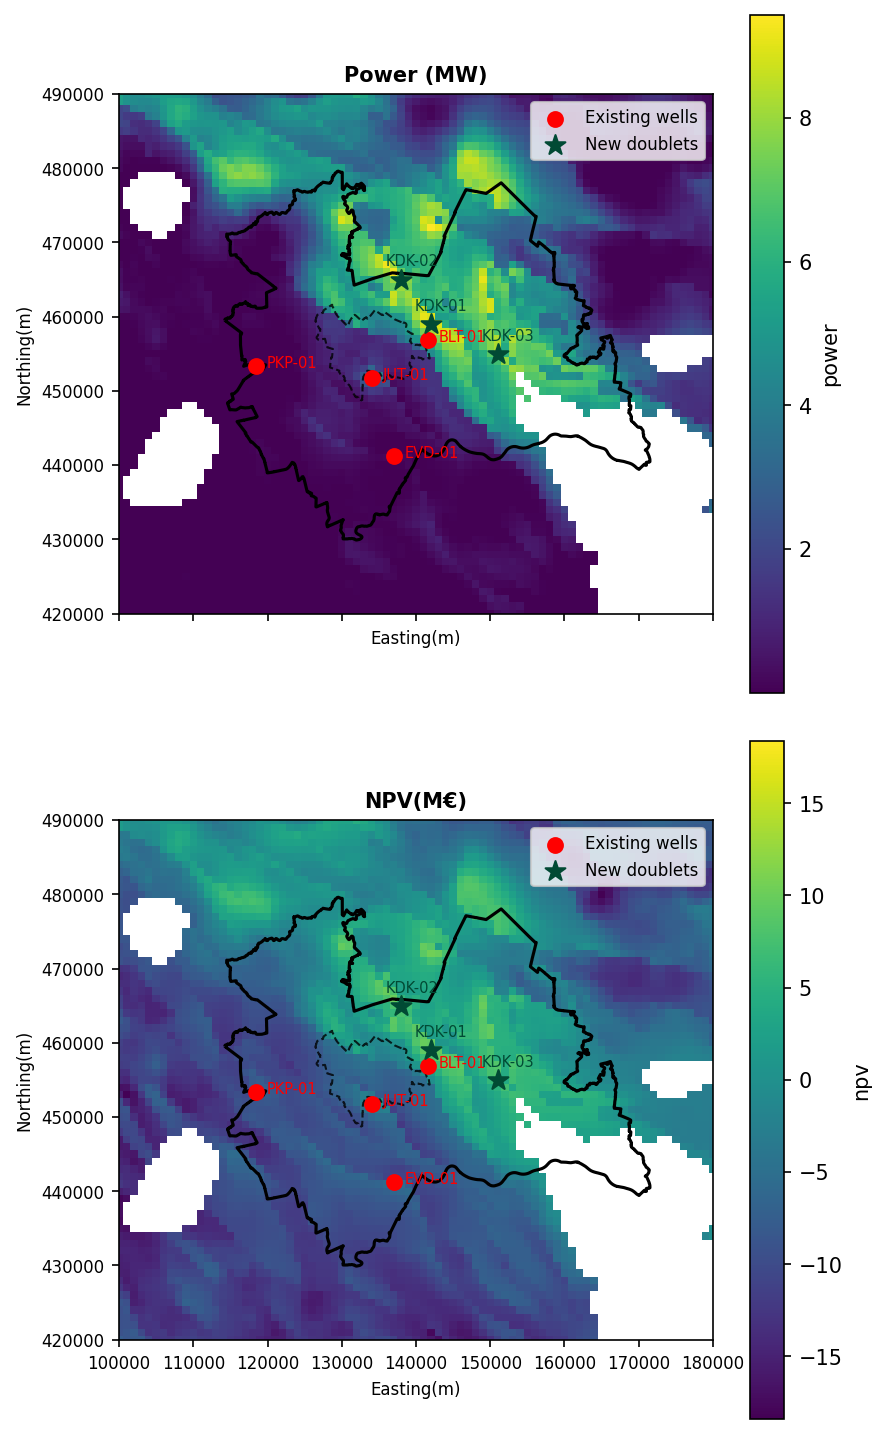

In [19]:
# output inputs
variables_to_plot = ["power","npv"]

variable_config = {
    "power": {"title" : "Power (MW)"},
    "npv": {"title" : "NPV(M€)"},
}

fig, axes = plt.subplots(
    nrows=len(variables_to_plot),
    ncols=1,
    figsize=(6, 5 * len(variables_to_plot)),
    sharex=True,
    sharey=True,
    dpi=150,
    squeeze=False,
)
axes = axes.ravel()

for i, variable in enumerate(variables_to_plot):
    ax = axes[i]
    cfg = variable_config[variable]

    im = plot_grid(
        stim_hp_results[variable], 
        axes=ax, 
        add_netherlands_shapefile=False,
        custom_shapefile=utrecht_province,
    )

    ax.set_xlim(minx_clip, maxx_clip)
    ax.set_ylim(miny_clip, maxy_clip)

    ax.set_xlabel("Easting(m)", fontsize=8)
    ax.set_ylabel("Northing(m)", fontsize=8)

    # Plot Utrecht city boundary
    utrecht_city.boundary.plot(
        ax=ax,
        edgecolor="black",
        linestyle="--",
        linewidth=1,
        alpha=0.8
    )

    # Existing wells
    for name, (x, y) in wells.items():
        ax.scatter(x, y, color="red", s=50, marker="o", zorder=5, label="Existing wells" if name == list(wells)[0] else "")
        ax.annotate(
            name,
            (x, y),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=7,
            color="red",
            zorder=6,
            ha="left",
            va="top",
        )

    # New doublets
    for name, (x, y) in new_doublets.items():
        ax.scatter(x, y, color="#014A34", s=100, marker="*", zorder=5, label="New doublets" if name == list(new_doublets)[0] else "")
        ax.annotate(
            name,
            (x, y),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=7,
            color="#014A34",
            zorder=6,
            ha="center",
            va="bottom",
        )

    ax.set_title(cfg["title"], fontsize=10, fontweight="bold")
    cbar = ax.images[-1].colorbar if ax.images else None
    if cbar is not None:
        cbar.set_label(cfg["title"], fontsize=9)
    ax.legend(loc="upper right", fontsize=8, framealpha=0.8)
plt.tight_layout()
plt.savefig(OUTPUT / "power_and_npv_map.png")